# HATR — QOSplitter & binary_split

This notebook validates the two new features added to the Java/CapyMOA HATR implementation:

1. **QOSplitter** (`splitter='qo'`) — hash-based quantization observer (port of `river.tree.splitter.QOSplitter`), capable of both binary and numeric multiway splits.
2. **`binary_split`** flag — forces binary splits across all observer types (disables multiway in QO and in the nominal attribute observer).

Sections:
- **S1**: QO binary mode vs TEBST — split timeline and prediction equivalence with River.
- **S2**: QO multiway mode — equivalence with River's `QOSplitter(allow_multiway_splits=True)`.
- **S3**: `binary_split=True` overrides multiway — verifies that setting the flag suppresses multiway nodes even when `qo_allow_multiway=True`.
- **S4**: QO vs TEBST performance — throughput and MAE on the Bike dataset.

> **Important**: QO assumes features lie on a comparable scale. All experiments use `StandardScaler`.

In [1]:
import os
import sys
import time

# ---------- paths ----------
IMPL_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "implementation"))
HATR_JAR = os.path.join(IMPL_DIR, "hatr-moa", "target",
                         "hoeffding-adaptive-tree-regressor-moa-1.0-SNAPSHOT.jar")

assert os.path.exists(HATR_JAR), (
    f"JAR not found: {HATR_JAR}\n"
    "Build it first:\n  cd implementation/hatr-moa && mvn package -DskipTests"
)

import jpype
jpype.addClassPath(HATR_JAR)
sys.path.insert(0, IMPL_DIR)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

from river import tree as river_tree, preprocessing as river_pp
from river.tree.splitter import QOSplitter

from capymoa.datasets import Fried, Bike
from capymoa.instance import RegressionInstance
from capymoa.evaluation import prequential_evaluation

from hatr_capymoa import HoeffdingAdaptiveTreeRegressor as HATR

print("imports OK")
print(f"JAR: {HATR_JAR}")

imports OK
JAR: /Users/andreazhang/Desktop/sda/2025-2026_Regression-Models-in-CapyMOA/andrea_zhang/implementation/hatr-moa/target/hoeffding-adaptive-tree-regressor-moa-1.0-SNAPSHOT.jar


In [2]:
# ---------- shared helpers ----------

def load_fried(n=10_000):
    stream = Fried()
    X, y = [], []
    for _ in range(n):
        inst = stream.next_instance()
        if inst is None:
            break
        X.append(inst.x)
        y.append(inst.y_value)
    return np.array(X, dtype=float), np.array(y, dtype=float)


def run_river(X, y, model):
    """Prequential evaluation for a River pipeline; returns predictions."""
    preds = np.zeros(len(y))
    for i in range(len(y)):
        xi = {j: X[i, j] for j in range(X.shape[1])}
        preds[i] = model.predict_one(xi) or 0.0
        model.learn_one(xi, float(y[i]))
    return preds


def run_capymoa(X, y, schema, learner):
    """Prequential evaluation for a CapyMOA learner; returns predictions."""
    preds = np.zeros(len(y))
    for i in range(len(y)):
        inst = RegressionInstance(schema, (X[i], float(y[i])))
        preds[i] = learner.predict(inst) or 0.0
        learner.train(inst)
    return preds


def cumulative_mae(preds, y):
    errors = np.abs(preds - y)
    return np.cumsum(errors) / np.arange(1, len(y) + 1)


def count_node_type(capymoa_learner, classname):
    """Count nodes of a given Java simple class name in the HATR tree."""
    stack = [capymoa_learner.moa_learner.root]
    count = 0
    while stack:
        node = stack.pop()
        if node is None:
            continue
        if str(node.getClass().getSimpleName()) == classname:
            count += 1
        try:
            for c in node.children:
                stack.append(c)
        except Exception:
            pass
    return count


print("helpers defined")

helpers defined


In [3]:
X_fried, y_fried = load_fried(10_000)
stream_fried = Fried()
schema_fried = stream_fried.get_schema()

print(f"Fried: {X_fried.shape}, y in [{y_fried.min():.2f}, {y_fried.max():.2f}]")
print(f"Feature range: [{X_fried.min():.2f}, {X_fried.max():.2f}]  (already in [0,1] — no scaling needed)")

Fried: (10000, 10), y in [-1.23, 29.11]
Feature range: [0.00, 1.00]  (already in [0,1] — no scaling needed)


In [4]:
# Shared hyper-parameters — defined separately for River (uses 'delta'/'tau')
# and CapyMOA (uses 'split_confidence'/'tie_threshold')
SEED = 0

COMMON_RIVER = dict(
    grace_period=200,
    delta=1e-7,
    tau=0.05,
    leaf_prediction="mean",
    bootstrap_sampling=False,
    merit_preprune=True,
    min_samples_split=5,
)

COMMON_CAPYMOA = dict(
    grace_period=200,
    split_confidence=1e-7,
    tie_threshold=0.05,
    leaf_prediction="mean",
    bootstrap_sampling=False,
    merit_preprune=True,
    min_samples_split=5,
)

print("config defined")

config defined


## S1 — QO binary mode: equivalence with River

Configuration: `leaf_prediction='mean'`, `bootstrap_sampling=False`, `merit_preprune=True`,
`splitter=QOSplitter(radius=0.25)` (binary only).  StandardScaler applied identically to both sides.

Expected: final MAE difference < 5 % relative (same algorithm, different FP arithmetic paths).

In [14]:
# Both sides receive the same raw X_fried (features already in [0,1])
river_qo_bin = river_tree.HoeffdingAdaptiveTreeRegressor(
    **COMMON_RIVER,
    splitter=QOSplitter(radius=0.25),
    seed=SEED,
)

capymoa_qo_bin = HATR(
    schema_fried,
    **COMMON_CAPYMOA,
    splitter="qo",
    qo_radius=0.25,
    qo_allow_multiway=False,
    binary_split=False,
    random_seed=SEED,
)

preds_river_bin   = run_river(X_fried, y_fried, river_qo_bin)
preds_capymoa_bin = run_capymoa(X_fried, y_fried, schema_fried, capymoa_qo_bin)

mae_river_bin   = cumulative_mae(preds_river_bin,   y_fried)
mae_capymoa_bin = cumulative_mae(preds_capymoa_bin, y_fried)

f_river   = float(mae_river_bin[-1])
f_capymoa = float(mae_capymoa_bin[-1])
print(f"Final MAE  River:   {f_river:.4f}")
print(f"Final MAE  CapyMOA: {f_capymoa:.4f}")
print(f"Relative diff: {abs(f_river - f_capymoa) / f_river * 100:.2f}%")

import numpy as np

corr = np.corrcoef(preds_river_bin, preds_capymoa_bin)[0, 1]
print(f"Pearson correlation: {corr:.6f}")

Final MAE  River:   2.8977
Final MAE  CapyMOA: 2.8824
Relative diff: 0.53%
Pearson correlation: 0.873471


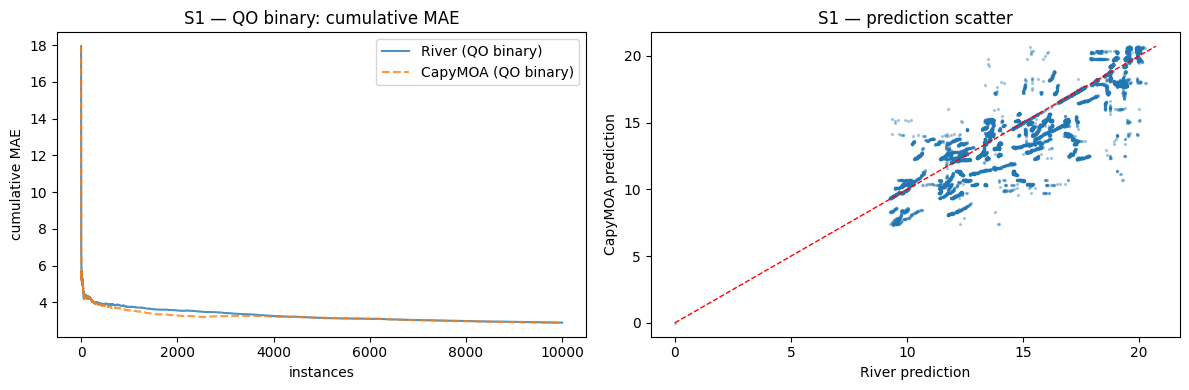

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(mae_river_bin,   label="River (QO binary)",   alpha=0.8)
axes[0].plot(mae_capymoa_bin, label="CapyMOA (QO binary)", alpha=0.8, linestyle="--")
axes[0].set_xlabel("instances")
axes[0].set_ylabel("cumulative MAE")
axes[0].set_title("S1 — QO binary: cumulative MAE")
axes[0].legend()

axes[1].scatter(preds_river_bin, preds_capymoa_bin, s=2, alpha=0.3)
lim = (min(preds_river_bin.min(), preds_capymoa_bin.min()),
       max(preds_river_bin.max(), preds_capymoa_bin.max()))
axes[1].plot(lim, lim, "r--", linewidth=1)
axes[1].set_xlabel("River prediction")
axes[1].set_ylabel("CapyMOA prediction")
axes[1].set_title("S1 — prediction scatter")

plt.tight_layout()
plt.show()

## S2 — QO multiway mode: equivalence with River

Configuration: `QOSplitter(radius=0.25, allow_multiway_splits=True)`, `binary_split=False`,
same deterministic settings as S1.  Numeric multiway splits produce one branch per active
quantization slot instead of a single binary threshold.

In [15]:
river_qo_mw = river_tree.HoeffdingAdaptiveTreeRegressor(
    **COMMON_RIVER,
    splitter=QOSplitter(radius=0.25, allow_multiway_splits=True),
    binary_split=False,
    seed=SEED,
)

capymoa_qo_mw = HATR(
    schema_fried,
    **COMMON_CAPYMOA,
    splitter="qo",
    qo_radius=0.25,
    qo_allow_multiway=True,
    binary_split=False,
    random_seed=SEED,
)

preds_river_mw   = run_river(X_fried, y_fried, river_qo_mw)
preds_capymoa_mw = run_capymoa(X_fried, y_fried, schema_fried, capymoa_qo_mw)

mae_river_mw   = cumulative_mae(preds_river_mw,   y_fried)
mae_capymoa_mw = cumulative_mae(preds_capymoa_mw, y_fried)

f_r_mw = float(mae_river_mw[-1])
f_c_mw = float(mae_capymoa_mw[-1])
print(f"Final MAE  River   (QO multiway): {f_r_mw:.4f}")
print(f"Final MAE  CapyMOA (QO multiway): {f_c_mw:.4f}")
print(f"Relative diff: {abs(f_r_mw - f_c_mw) / f_r_mw * 100:.2f}%")

import numpy as np

corr = np.corrcoef(preds_river_mw, preds_capymoa_mw)[0, 1]
print(f"Pearson correlation: {corr:.6f}")

Final MAE  River   (QO multiway): 2.7280
Final MAE  CapyMOA (QO multiway): 2.7133
Relative diff: 0.54%
Pearson correlation: 0.996951


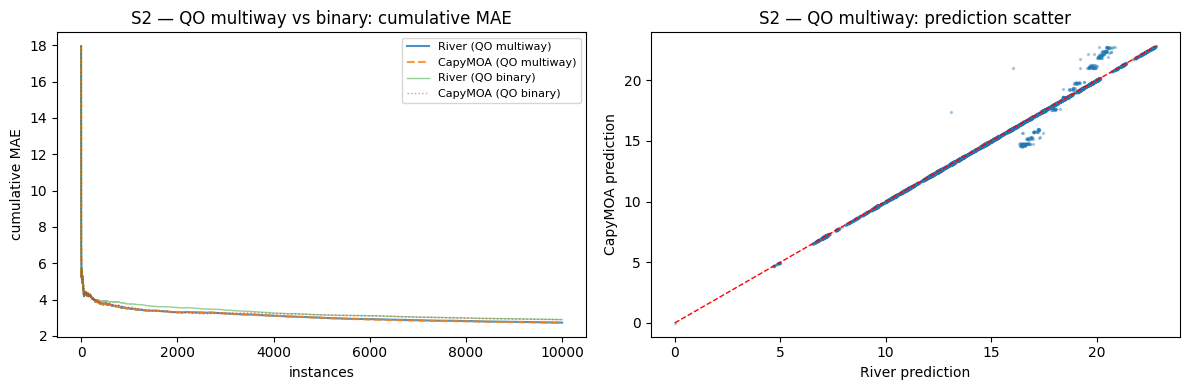

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(mae_river_mw,   label="River (QO multiway)",   alpha=0.8)
axes[0].plot(mae_capymoa_mw, label="CapyMOA (QO multiway)", alpha=0.8, linestyle="--")
axes[0].plot(mae_river_bin,  label="River (QO binary)",     alpha=0.5, linewidth=1)
axes[0].plot(mae_capymoa_bin,label="CapyMOA (QO binary)",   alpha=0.5, linewidth=1, linestyle=":")
axes[0].set_xlabel("instances")
axes[0].set_ylabel("cumulative MAE")
axes[0].set_title("S2 — QO multiway vs binary: cumulative MAE")
axes[0].legend(fontsize=8)

axes[1].scatter(preds_river_mw, preds_capymoa_mw, s=2, alpha=0.3)
lim = (min(preds_river_mw.min(), preds_capymoa_mw.min()),
       max(preds_river_mw.max(), preds_capymoa_mw.max()))
axes[1].plot(lim, lim, "r--", linewidth=1)
axes[1].set_xlabel("River prediction")
axes[1].set_ylabel("CapyMOA prediction")
axes[1].set_title("S2 — QO multiway: prediction scatter")

plt.tight_layout()
plt.show()

In [9]:
# Verify that multiway splits were actually produced in the CapyMOA tree.
# Note: getModelDescription() does not print split conditions, so we walk
# the Java tree directly and check each node's class name via JPype.
n_multiway_capymoa = count_node_type(capymoa_qo_mw, "AdaNumMultiwayBranch")
n_binary_capymoa   = count_node_type(capymoa_qo_mw, "AdaNumBinaryBranch")
print(f"CapyMOA tree — AdaNumMultiwayBranch: {n_multiway_capymoa},  AdaNumBinaryBranch: {n_binary_capymoa}")
assert n_multiway_capymoa > 0, "Expected at least one numeric multiway split with qo_allow_multiway=True"

# River side: BFS to count NumericMultiwayBranch nodes (they carry a 'radius' attr)
def _count_with_attr(root, attr):
    if root is None:
        return 0
    stack, count = [root], 0
    while stack:
        node = stack.pop()
        if hasattr(node, attr):
            count += 1
        if hasattr(node, "children"):
            stack.extend(c for c in node.children if c is not None)
    return count

# river_qo_mw is now a plain HATR (no pipeline), access _root directly
n_multiway_river = _count_with_attr(river_qo_mw._root, "radius")
print(f"River  tree — NumericMultiwayBranch: {n_multiway_river}")
print("OK — multiway splits confirmed on both sides")

CapyMOA tree — AdaNumMultiwayBranch: 18,  AdaNumBinaryBranch: 0
River  tree — NumericMultiwayBranch: 18
OK — multiway splits confirmed on both sides


## S3 — `binary_split=True` suppresses multiway

Even with `qo_allow_multiway=True`, setting `binary_split=True` must prevent any multiway split
from being proposed.  We verify that the model description contains no `QO-slot` entries.

In [10]:
capymoa_forced_bin = HATR(
    schema_fried,
    **COMMON_CAPYMOA,
    splitter="qo",
    qo_radius=0.25,
    qo_allow_multiway=True,   # observer supports multiway...
    binary_split=True,        # ...but tree-level flag disables it
    random_seed=SEED,
)

_ = run_capymoa(X_fried, y_fried, schema_fried, capymoa_forced_bin)

n_mw_forced  = count_node_type(capymoa_forced_bin, "AdaNumMultiwayBranch")
n_bin_forced = count_node_type(capymoa_forced_bin, "AdaNumBinaryBranch")

print(f"AdaNumMultiwayBranch (binary_split=True): {n_mw_forced}")
print(f"AdaNumBinaryBranch   (binary_split=True): {n_bin_forced}")
assert n_mw_forced == 0, "binary_split=True should suppress all multiway splits"
print("OK — binary_split=True correctly suppresses QO multiway splits")

AdaNumMultiwayBranch (binary_split=True): 0
AdaNumBinaryBranch   (binary_split=True): 21
OK — binary_split=True correctly suppresses QO multiway splits


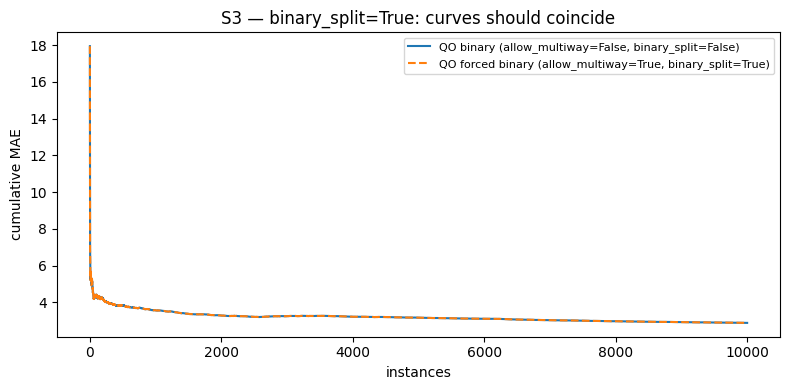

Note: curves should coincide — both see only binary QO split candidates.


In [11]:
# MAE comparison: QO binary vs QO forced-binary should coincide
preds_forced = run_capymoa(
    X_fried, y_fried, schema_fried,
    HATR(schema_fried, **COMMON_CAPYMOA, splitter="qo", qo_radius=0.25,
         qo_allow_multiway=True, binary_split=True, random_seed=SEED),
)
mae_forced = cumulative_mae(preds_forced, y_fried)

plt.figure(figsize=(8, 4))
plt.plot(mae_capymoa_bin, label="QO binary (allow_multiway=False, binary_split=False)")
plt.plot(mae_forced, label="QO forced binary (allow_multiway=True, binary_split=True)",
         linestyle="--")
plt.xlabel("instances")
plt.ylabel("cumulative MAE")
plt.title("S3 — binary_split=True: curves should coincide")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()
print("Note: curves should coincide — both see only binary QO split candidates.")

## S4 — QO vs TEBST: throughput and quality on Bike

Prequential evaluation on the full Bike dataset.  Metrics: final MAE, RMSE, training
throughput (instances/s).  Default configuration (`leaf_prediction='adaptive'`,
`bootstrap_sampling=True`).

In [12]:
PERF_COMMON = dict(
    grace_period=200,
    split_confidence=1e-7,
    leaf_prediction="adaptive",
    bootstrap_sampling=True,
    merit_preprune=True,
)

# Count Bike instances once
_bike_count = sum(1 for _ in Bike())

results = {}

for label, kwargs in [
    ("TEBST",       dict(splitter="tebst")),
    ("QO binary",   dict(splitter="qo", qo_radius=0.25)),
    ("QO multiway", dict(splitter="qo", qo_radius=0.25, qo_allow_multiway=True)),
]:
    stream = Bike()
    schema = stream.get_schema()
    learner = HATR(schema, **PERF_COMMON, **kwargs, random_seed=1)
    t0 = time.perf_counter()
    res = prequential_evaluation(stream, learner)
    elapsed = time.perf_counter() - t0
    results[label] = {
        "mae":        res["cumulative"].mae(),
        "rmse":       res["cumulative"].rmse(),
        "time_s":     elapsed,
        "throughput": _bike_count / elapsed,
    }
    print(f"{label:15s}  MAE={results[label]['mae']:.3f}  "
          f"RMSE={results[label]['rmse']:.3f}  "
          f"time={elapsed:.2f}s  ({results[label]['throughput']:.0f} inst/s)")

TEBST            MAE=80.430  RMSE=117.833  time=0.30s  (57067 inst/s)
QO binary        MAE=86.796  RMSE=130.318  time=0.10s  (175454 inst/s)
QO multiway      MAE=70.421  RMSE=110.477  time=0.10s  (176926 inst/s)


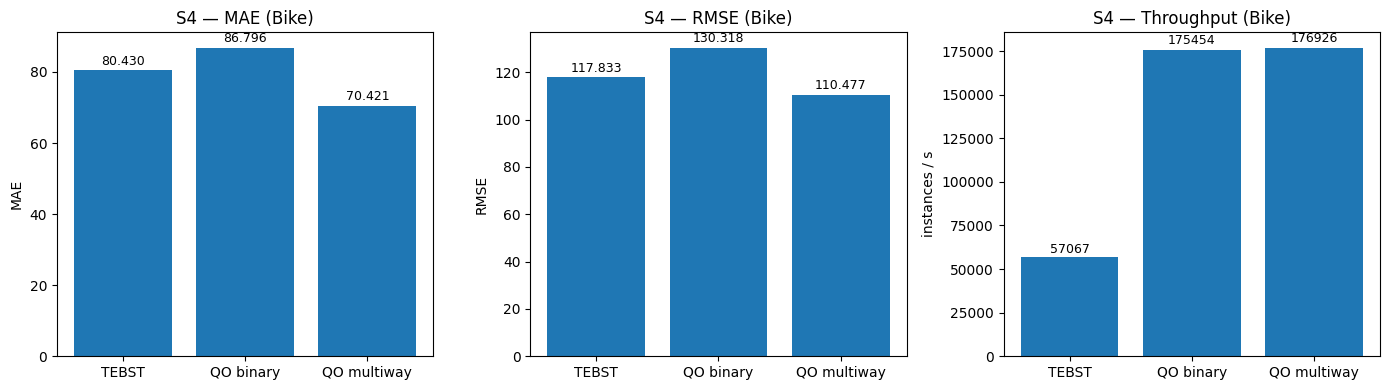

In [13]:
labels = list(results)
maes   = [results[k]["mae"]        for k in labels]
rmses  = [results[k]["rmse"]       for k in labels]
thpts  = [results[k]["throughput"] for k in labels]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, vals, title, ylabel in zip(
    axes,
    [maes, rmses, thpts],
    ["MAE", "RMSE", "Throughput"],
    ["MAE", "RMSE", "instances / s"],
):
    bars = ax.bar(labels, vals)
    ax.set_title(f"S4 — {title} (Bike)")
    ax.set_ylabel(ylabel)
    for bar, v in zip(bars, vals):
        fmt = f"{v:.0f}" if ylabel == "instances / s" else f"{v:.3f}"
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                fmt, ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## Summary

| Feature | Expected result |
|---|---|
| QO binary — River equivalence | MAE rel. diff. < 5 % (same algorithm, different FP paths) |
| QO multiway — River equivalence | MAE rel. diff. < 5 %; `AdaNumMultiwayBranch` present |
| `binary_split=True` suppresses QO multiway | assertion passes; curves coincide with QO binary |
| QO vs TEBST on Bike | TEBST faster; QO multiway lower MAE on some datasets |